<a href="https://colab.research.google.com/github/ashlsylee/nemotron-persona-eda/blob/main/data_set_analysis_.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Nemotron-Personas-Korea 데이터셋 EDA

이 노트북은 NVIDIA가 공개한 [`nvidia/Nemotron-Personas-Korea`](https://huggingface.co/datasets/nvidia/Nemotron-Personas-Korea) 데이터셋에 대한 상세 탐색적 데이터 분석(EDA)입니다.

**데이터셋 개요**
- 대한민국의 실제 인구통계·지리·직업 분포(KOSIS 국가통계포털, 대법원, 국민건강보험공단 등)를 기반으로 생성된 **완전 합성(synthetic)** 페르소나 데이터셋
- 100만 개(1,000,000) 행, 26개 컬럼, 만 19세 이상 성인만 포함
- 각 행은 하나의 가상 인물(persona)이며, 인구통계 속성(성별·나이·학력·직업·거주지 등)과 자연어로 작성된 7종의 페르소나 설명, 취미·기술 리스트 등을 포함
- 라이선스: CC BY 4.0

**이 노트북에서 다루는 내용**
1. 데이터 로드 및 기본 정보 확인 (구조, 결측치, 타입)
2. 인구통계 분석 (성별, 연령, 혼인상태, 병역, 가구유형, 주거유형)
3. 학력/전공 분석
4. 지역(시도·시군구) 분석
5. 직업 분석 (전체 분포, 성별 구성)
6. 페르소나 텍스트 분석 (길이 분포, 상관관계)
7. 취미·기술 리스트 분석 (빈도 Top N)
8. 교차 분석 및 종합 요약 테이블 저장

모든 그래프와 표는 재현 가능하도록 코드로 작성되어 있으며, 각 섹션은 **표(DataFrame) + 그래프(matplotlib)** 쌍으로 구성됩니다.


## 0. 환경 설정

필요한 라이브러리를 설치하고, 한글이 그래프에 깨지지 않도록 나눔고딕 폰트를 설정합니다. (Colab 등 리눅스 환경 기준. 로컬 macOS/Windows 환경이라면 이미 한글 폰트가 있으므로 `apt-get` 설치 셀은 건너뛰어도 됩니다.)

In [1]:
# 필요한 패키지 설치 (Colab/최초 실행 시 1회)
!pip install -q datasets pandas matplotlib pyarrow
!apt-get -qq -y install fonts-nanum > /dev/null 2>&1


In [2]:
import warnings
warnings.filterwarnings("ignore")

import ast
from collections import Counter

import matplotlib.font_manager as fm
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# ---- 한글 폰트 설정 ----
NANUM_PATH = "/usr/share/fonts/truetype/nanum/NanumGothic.ttf"
try:
    fm.fontManager.addfont(NANUM_PATH)
    plt.rcParams["font.family"] = "NanumGothic"
except FileNotFoundError:
    # 나눔고딕이 없는 환경(로컬 macOS 등)에서는 시스템 기본 한글 폰트를 사용하세요.
    plt.rcParams["font.family"] = "AppleGothic"  # macOS 예시
plt.rcParams["axes.unicode_minus"] = False

# ---- 차트 공통 스타일 ----
plt.rcParams["axes.spines.top"] = False
plt.rcParams["axes.spines.right"] = False
plt.rcParams["axes.edgecolor"] = "#c3c2b7"
plt.rcParams["axes.labelcolor"] = "#0b0b0b"
plt.rcParams["text.color"] = "#0b0b0b"
plt.rcParams["xtick.color"] = "#52514e"
plt.rcParams["ytick.color"] = "#52514e"
plt.rcParams["grid.color"] = "#e1e0d9"
plt.rcParams["figure.facecolor"] = "#fcfcfb"
plt.rcParams["axes.facecolor"] = "#fcfcfb"
plt.rcParams["savefig.facecolor"] = "#fcfcfb"

# ---- 공통 색상 팔레트 (카테고리 8색 고정 순서 + 시퀀셜 블루) ----
CAT = ["#2a78d6", "#1baf7a", "#eda100", "#008300", "#4a3aa7", "#e34948", "#e87ba4", "#eb6834"]
BLUE = "#2a78d6"
RED = "#e34948"
MUTED = "#898781"

pd.set_option("display.max_columns", 40)
pd.set_option("display.width", 140)


## 1. 데이터 로드

전체 데이터는 100만 행(약 4~5GB in-memory)이라 메모리가 제한된 환경(Colab 무료 티어 등)에서는 부담이 될 수 있습니다.
아래 `SAMPLE_SIZE`를 조절해 분석 규모를 정할 수 있습니다.

- `SAMPLE_SIZE = None` → 전체 100만 행 사용 (충분한 RAM 필요, 8GB 이상 권장)
- `SAMPLE_SIZE = 200_000` (기본값) → 무작위 20만 행 샘플. 100만 행 대비 표본오차가 매우 작아 전체 분포를 사실상 그대로 반영하면서 속도/메모리 부담을 크게 줄여줍니다.


In [3]:
from datasets import load_dataset

dataset = load_dataset("nvidia/Nemotron-Personas-Korea")
dataset


DatasetDict({
    train: Dataset({
        features: ['uuid', 'professional_persona', 'sports_persona', 'arts_persona', 'travel_persona', 'culinary_persona', 'family_persona', 'persona', 'cultural_background', 'skills_and_expertise', 'skills_and_expertise_list', 'hobbies_and_interests', 'hobbies_and_interests_list', 'career_goals_and_ambitions', 'sex', 'age', 'marital_status', 'military_status', 'family_type', 'housing_type', 'education_level', 'bachelors_field', 'occupation', 'district', 'province', 'country'],
        num_rows: 1000000
    })
})

In [4]:
SAMPLE_SIZE = 200_000  # None 으로 바꾸면 전체 100만 행 사용
RANDOM_STATE = 42

if SAMPLE_SIZE is None:
    df = dataset["train"].to_pandas()
else:
    df = dataset["train"].shuffle(seed=RANDOM_STATE).select(range(SAMPLE_SIZE)).to_pandas()

df.shape


(200000, 26)

## 2. 데이터 기본 정보

In [5]:
df.head(3)


,uuid,professional_persona,sports_persona,arts_persona,travel_persona,culinary_persona,family_persona,persona,cultural_background,skills_and_expertise,skills_and_expertise_list,hobbies_and_interests,hobbies_and_interests_list,career_goals_and_ambitions,sex,age,marital_status,military_status,family_type,housing_type,education_level,bachelors_field,occupation,district,province,country
0,a2996e70e32b47198b0fbdcef86a5d4c,변임식 씨는 학교 경비실 창틀에 턱을 괴고 정문을 지나가는 이들의 걸음걸이만 봐도 ...,변임식 씨는 주말이면 안동호의 고요한 물가에 낚싯대를 드리우고 찌가 움직이기를 기다...,변임식 씨는 거실 소파에 앉아 TV 속 트로트 가수의 노래에 박자를 맞추며 하루의 ...,변임식 씨는 성당 교우들과 함께 대형 버스를 타고 전국 곳곳의 성지를 순례하며 신앙...,변임식 씨는 동네 단골 두부집에서 갓 나온 따끈한 순두부찌개로 식사하는 일을 일주일...,변임식 씨는 안동의 엄격한 유교 가풍 속에서 자라나 겉으로는 무뚝뚝하지만 아내가 좋...,"변임식 씨는 안동의 보수적인 가치관과 성당의 신앙심을 동시에 지닌 채, 소박한 일상...","안동의 보수적인 유교 문화권에서 나고 자라 예의와 체면을 중시하며, 초등학교 졸업 ...","교육 시설의 경비원으로 근무하며 외부인 출입 통제와 시설물 안전 점검에 능숙하며, ...","['CCTV 모니터링 및 이상 징후 포착', '시설물 보안 및 출입자 명부 관리',...","주말이면 안동호 인근에서 낚싯대를 드리우고 시간을 보내며, 평소에는 성당 교우들과 ...","['안동호 민물낚시', '천주교 성지순례 여행', '동네 산책 및 낮잠', '롯데리...","거창한 성취보다는 건강이 허락하는 한 지금의 경비 업무를 계속하며, 매달 들어오는 ...",남자,74,배우자있음,비현역,배우자와 거주,단독주택,초등학교,해당없음,시설 경비원,경상북-안동시,경상북,대한민국
1,813b796a34564ece9b8d99a6d89dfd0b,한가은 씨는 경영학과 법학 지식을 활용해 복잡한 계약서의 허점을 찾아내는 데 능숙하...,한가은 씨는 땀 흘리는 격렬한 운동보다는 기흥호수공원 산책로를 천천히 걷거나 아무것...,한가은 씨는 수원 행궁동의 개성 있는 테마 카페를 찾아다니며 공간이 주는 미감을 사...,한가은 씨는 가평의 글램핑장에서 타오르는 장작불을 보며 멍하니 시간을 보내는 불멍 ...,"한가은 씨는 주 4회 이상 외식을 하며, 특히 BHC 뿌링클 치킨에 맥주를 곁들이는...",한가은 씨는 용인시 기흥구의 아파트에서 부모님과 함께 지내며 보호받는 안락함을 누리...,"한가은 씨는 실리를 추구하는 경영학 전공의 취업 준비생으로, 도시의 편리함 속에서 ...",기흥호수공원 인근 아파트 단지에서 성장하며 도시의 편리함과 외곽의 여유를 동시에 경...,복잡한 이용 약관이나 계약서의 허점을 빠르게 찾아내어 자신에게 유리한 조건을 도출하...,"['소비자 약관 및 계약서 분석', '인스타그램 기반 핫플레이스 큐레이션', '모임...","주말이면 수원 행궁동의 개성 있는 테마 카페를 찾아다니며 사진을 찍고, 저녁에는 B...","['행궁동 테마 카페 투어', '유튜브 쇼츠 및 릴스 시청', '가평 글램핑과 불멍...",거창한 자아실현보다는 정시 퇴근이 보장되고 연봉 협상이 명확한 실속 있는 직장을 구...,여자,27,미혼,비현역,부모와 동거,아파트,4년제 대학교,경영·행정·법,무직,경기-용인시 기흥구,경기,대한민국
2,ee5e6eaeb12c435582163565322c4cae,임재광 씨는 용인 기흥의 기계 제조 공장에서 배전반 회로의 미세한 오결선 하나까지 ...,임재광 씨는 주말 저녁 거실 소파에 깊숙이 몸을 파묻고 TV로 KBO 리그 경기를 ...,"임재광 씨는 인터넷과 영상 매체를 통해 최신 정보와 트렌드를 습득하는 것을 즐기며,...",임재광 씨는 가족들과 함께 전남 보성의 꼬막정식집이나 전북 순창의 보리밥집 같은 전...,임재광 씨는 2주에 한 번 정도 가족 외식을 하며 고기구이보다는 정갈한 나물 반찬이...,임재광 씨는 아내와 아이들이 심리적 안정감을 느낄 수 있는 내 집 마련을 가장 큰 ...,"임재광 씨는 교육학 전공의 섬세함으로 배전반을 조작하는 성실한 기술자이자, 가족과 ...","용인 기흥의 계획도시 분위기 속에서 생활하며, 사범대 졸업 후 제조업 현장이라는 전...",배전반의 복잡한 회로도 속에서 단 하나의 오결선도 허용하지 않는 치밀함으로 공정의 ...,"['배전반 회로 설계 및 점검', '전기 설비 유지보수', '기술 교육 매뉴얼 작성...",주말이면 가족들과 함께 전라도나 경상도의 이름난 보리밥집이나 꼬막정식집을 찾아다니는...,"['지역별 제철 한식 맛집 탐방', '프로야구 경기 시청', '반려견 산책 및 케어...",전기기사 자격증을 취득하여 단순 조작원을 넘어 공정 전체를 설계하고 관리하는 책임자...,남자,48,배우자있음,비현역,배우자·자녀와 거주,아파트,4년제 대학교,교육,배전반 조작원,경기-용인시 기흥구,경기,대한민국


In [6]:
df.info()


<class 'pandas.DataFrame'>
RangeIndex: 200000 entries, 0 to 199999
Data columns (total 26 columns):
 #   Column                      Non-Null Count   Dtype
---  ------                      --------------   -----
 0   uuid                        200000 non-null  str  
 1   professional_persona        200000 non-null  str  
 2   sports_persona              200000 non-null  str  
 3   arts_persona                200000 non-null  str  
 4   travel_persona              200000 non-null  str  
 5   culinary_persona            200000 non-null  str  
 6   family_persona              200000 non-null  str  
 7   persona                     200000 non-null  str  
 8   cultural_background         200000 non-null  str  
 9   skills_and_expertise        200000 non-null  str  
 10  skills_and_expertise_list   200000 non-null  str  
 11  hobbies_and_interests       200000 non-null  str  
 12  hobbies_and_interests_list  200000 non-null  str  
 13  career_goals_and_ambitions  200000 non-null  str  
 14 

In [7]:
missing = df.isnull().sum()
missing_table = missing[missing > 0].to_frame("결측치_개수")
if missing_table.empty:
    print("결측치가 있는 컬럼이 없습니다. (합성 데이터 특성상 모든 필드가 채워져 있음)")
missing_table


결측치가 있는 컬럼이 없습니다. (합성 데이터 특성상 모든 필드가 채워져 있음)


,결측치_개수


In [8]:
nunique_table = df.nunique().sort_values(ascending=False).to_frame("고유값_개수")
nunique_table


,고유값_개수
uuid,200000
professional_persona,200000
sports_persona,200000
arts_persona,200000
travel_persona,200000
culinary_persona,200000
family_persona,200000
persona,200000
cultural_background,200000
skills_and_expertise,200000


## 3. 인구통계 분석

### 3.1 성별 분포

In [9]:
sex_counts = df["sex"].value_counts()
sex_table = sex_counts.to_frame("인원수")
sex_table["비율(%)"] = (sex_table["인원수"] / len(df) * 100).round(2)
sex_table


,인원수,비율(%)
sex,,
여자,100914,50.46
남자,99086,49.54


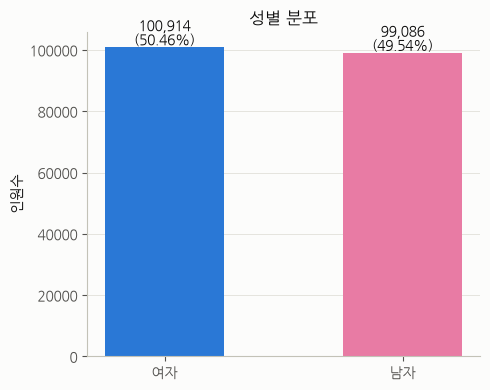

In [10]:
fig, ax = plt.subplots(figsize=(5, 4))
ax.bar(sex_table.index, sex_table["인원수"], color=[CAT[0], CAT[6]], width=0.5)
for i, (v, p) in enumerate(zip(sex_table["인원수"], sex_table["비율(%)"])):
    ax.text(i, v, f"{v:,}\n({p}%)", ha="center", va="bottom")
ax.set_title("성별 분포")
ax.set_ylabel("인원수")
ax.grid(axis="y", linewidth=0.6)
ax.set_axisbelow(True)
plt.tight_layout()
plt.show()


### 3.2 연령 분포

In [11]:
age_stats = df["age"].describe().to_frame("age")
age_stats


,age
count,200000.000000
mean,50.688175
std,17.631894
min,19.000000
25%,36.000000
50%,51.000000
75%,64.000000
max,99.000000


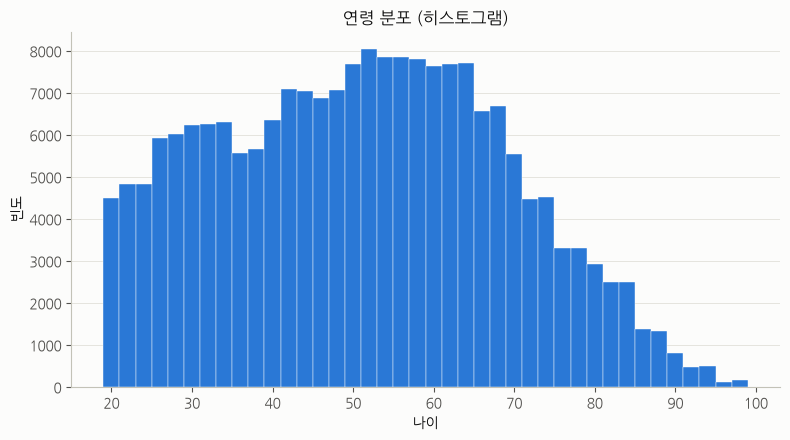

In [12]:
fig, ax = plt.subplots(figsize=(8, 4.5))
ax.hist(df["age"], bins=40, color=BLUE, edgecolor="white", linewidth=0.3)
ax.set_title("연령 분포 (히스토그램)")
ax.set_xlabel("나이")
ax.set_ylabel("빈도")
ax.grid(axis="y", linewidth=0.6)
ax.set_axisbelow(True)
plt.tight_layout()
plt.show()


In [13]:
bins = [19, 30, 40, 50, 60, 70, 80, 100]
age_labels = ["19-29", "30대", "40대", "50대", "60대", "70대", "80+"]
df["age_group"] = pd.cut(df["age"], bins=bins, labels=age_labels, right=False)

age_group_table = df["age_group"].value_counts().sort_index().to_frame("인원수")
age_group_table["비율(%)"] = (age_group_table["인원수"] / len(df) * 100).round(2)
age_group_table


,인원수,비율(%)
age_group,,
19-29,29164,14.58
30대,29814,14.91
40대,35165,17.58
50대,39591,19.80
60대,35730,17.87
70대,19480,9.74
80+,11056,5.53


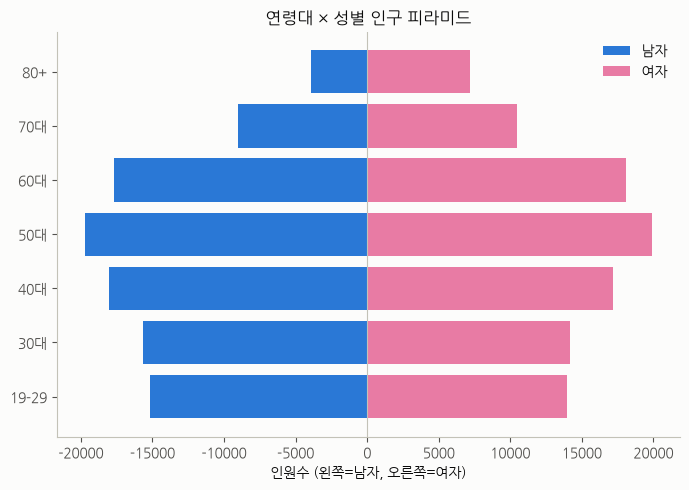

In [14]:
age_sex = df.groupby(["age_group", "sex"], observed=True).size().unstack(fill_value=0)
male_col = [c for c in age_sex.columns if c == "남자"][0]
female_col = [c for c in age_sex.columns if c == "여자"][0]

fig, ax = plt.subplots(figsize=(7, 5))
y = np.arange(len(age_sex.index))
ax.barh(y, -age_sex[male_col].values, color=CAT[0], label="남자")
ax.barh(y, age_sex[female_col].values, color=CAT[6], label="여자")
ax.set_yticks(y)
ax.set_yticklabels(age_sex.index)
ax.axvline(0, color="#c3c2b7", linewidth=0.8)
ax.set_title("연령대 × 성별 인구 피라미드")
ax.set_xlabel("인원수 (왼쪽=남자, 오른쪽=여자)")
ax.legend(frameon=False)
plt.tight_layout()
plt.show()


> 60대 이상 구간에서 여성 비중이 뚜렷하게 커지는 항아리형 인구구조가 나타납니다. 이는 실제 대한민국의 저출산·고령화 및 고령층 여성 기대수명 우위를 반영한 결과입니다.

### 3.3 혼인상태 분포

In [15]:
marital_table = df["marital_status"].value_counts().to_frame("인원수")
marital_table["비율(%)"] = (marital_table["인원수"] / len(df) * 100).round(2)
marital_table


,인원수,비율(%)
marital_status,,
배우자있음,118587,59.29
미혼,51187,25.59
사별,17592,8.80
이혼,12634,6.32


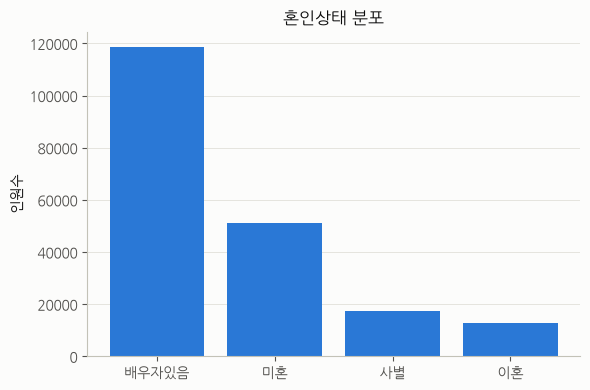

In [16]:
fig, ax = plt.subplots(figsize=(6, 4))
ax.bar(marital_table.index, marital_table["인원수"], color=BLUE)
ax.set_title("혼인상태 분포")
ax.set_ylabel("인원수")
ax.grid(axis="y", linewidth=0.6)
ax.set_axisbelow(True)
plt.tight_layout()
plt.show()


### 3.4 연령대별 혼인상태 구성비

In [17]:
age_marital = pd.crosstab(df["age_group"], df["marital_status"], normalize="index") * 100
age_marital = age_marital[["미혼", "배우자있음", "이혼", "사별"]].round(1)
age_marital


marital_status,미혼,배우자있음,이혼,사별
age_group,,,,
19-29,90.9,8.5,0.5,0.1
30대,44.5,52.6,2.4,0.5
40대,19.5,71.9,7.6,1.1
50대,8.0,76.7,11.5,3.8
60대,3.1,76.7,9.6,10.6
70대,1.2,66.6,4.7,27.5
80+,0.8,39.9,1.5,57.8


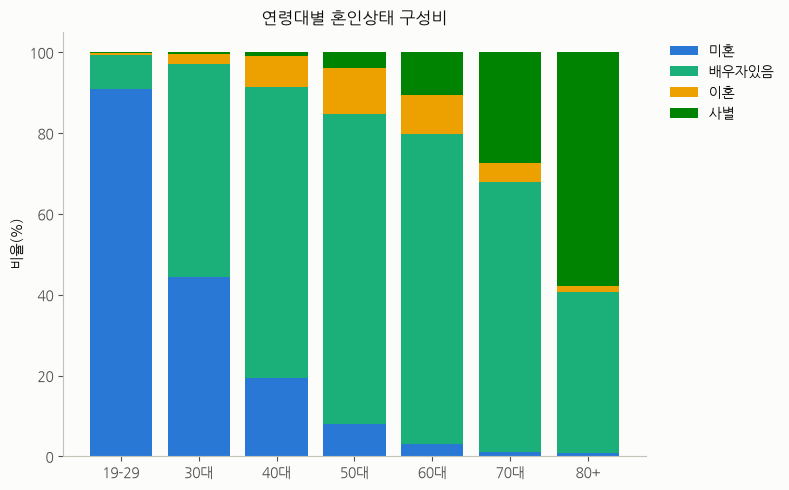

In [18]:
fig, ax = plt.subplots(figsize=(8, 5))
bottom = np.zeros(len(age_marital))
for i, col in enumerate(age_marital.columns):
    ax.bar(age_marital.index, age_marital[col], bottom=bottom, color=CAT[i], label=col)
    bottom += age_marital[col].values
ax.set_title("연령대별 혼인상태 구성비")
ax.set_ylabel("비율(%)")
ax.legend(frameon=False, bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.show()


### 3.5 가구 유형 (Top 10)

In [19]:
family_type_table = df["family_type"].value_counts().head(10).to_frame("인원수")
family_type_table["비율(%)"] = (family_type_table["인원수"] / len(df) * 100).round(2)
family_type_table


,인원수,비율(%)
family_type,,
배우자·자녀와 거주,54114,27.06
배우자와 거주,41534,20.77
혼자 거주,27931,13.97
부모와 동거,18237,9.12
기타2세대,7993,4.00
어머니와 동거,7510,3.76
자녀와 거주 (한부모),6583,3.29
기타3세대,5782,2.89
혼자 거주 (배우자 별거),4703,2.35


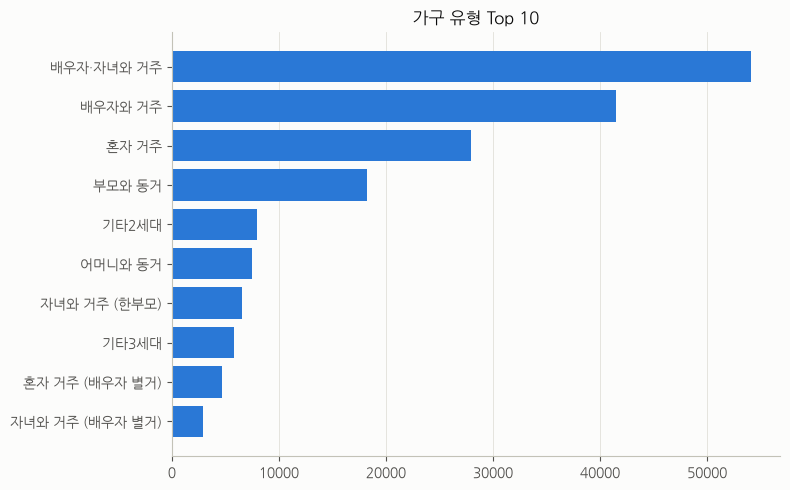

In [20]:
fig, ax = plt.subplots(figsize=(8, 5))
ax.barh(family_type_table.index[::-1], family_type_table["인원수"][::-1], color=BLUE)
ax.set_title("가구 유형 Top 10")
ax.grid(axis="x", linewidth=0.6)
ax.set_axisbelow(True)
plt.tight_layout()
plt.show()


### 3.6 주거 유형 분포

In [21]:
housing_table = df["housing_type"].value_counts().to_frame("인원수")
housing_table["비율(%)"] = (housing_table["인원수"] / len(df) * 100).round(2)
housing_table


,인원수,비율(%)
housing_type,,
아파트,124320,62.16
단독주택,33764,16.88
다세대주택,22811,11.41
주택 이외의 거처,11941,5.97
연립주택,5200,2.60
비주거용 건물 내 주택,1964,0.98


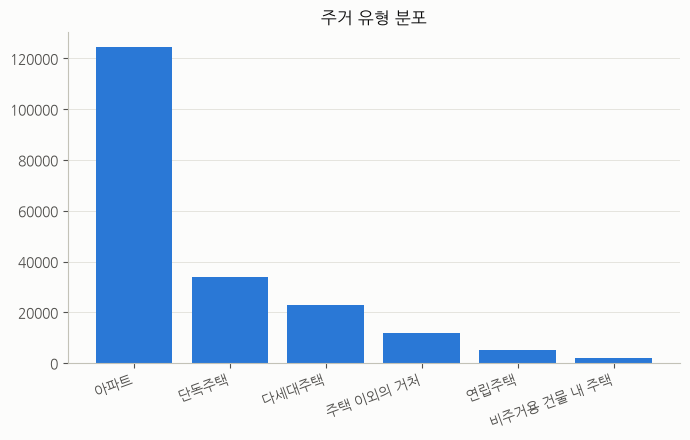

In [22]:
fig, ax = plt.subplots(figsize=(7, 4.5))
ax.bar(housing_table.index, housing_table["인원수"], color=BLUE)
ax.set_title("주거 유형 분포")
plt.xticks(rotation=20, ha="right")
ax.grid(axis="y", linewidth=0.6)
ax.set_axisbelow(True)
plt.tight_layout()
plt.show()


## 4. 학력 · 전공 분석

### 4.1 학력 분포

In [23]:
edu_order = ["무학", "초등학교", "중학교", "고등학교", "2~3년제 전문대학", "4년제 대학교", "대학원"]
edu_table = df["education_level"].value_counts().reindex(edu_order).to_frame("인원수")
edu_table["비율(%)"] = (edu_table["인원수"] / len(df) * 100).round(2)
edu_table


,인원수,비율(%)
education_level,,
무학,5303,2.65
초등학교,16333,8.17
중학교,17159,8.58
고등학교,66321,33.16
2~3년제 전문대학,29910,14.95
4년제 대학교,54127,27.06
대학원,10847,5.42


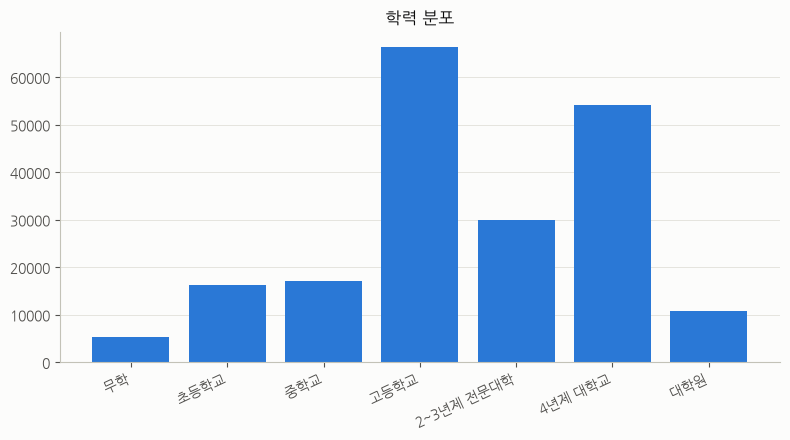

In [24]:
fig, ax = plt.subplots(figsize=(8, 4.5))
ax.bar(edu_table.index, edu_table["인원수"], color=BLUE)
ax.set_title("학력 분포")
plt.xticks(rotation=25, ha="right")
ax.grid(axis="y", linewidth=0.6)
ax.set_axisbelow(True)
plt.tight_layout()
plt.show()


### 4.2 전공계열 분포 (대졸 이상, `해당없음` 제외)

In [25]:
field_table = df.loc[df["bachelors_field"] != "해당없음", "bachelors_field"].value_counts().to_frame("인원수")
field_table["비율(%)"] = (field_table["인원수"] / field_table["인원수"].sum() * 100).round(2)
field_table


,인원수,비율(%)
bachelors_field,,
공학·제조·건설,13605,20.94
경영·행정·법,10839,16.68
예술·인문,9747,15.00
보건·복지,7008,10.79
교육,6335,9.75
정보통신기술,5743,8.84
서비스,3699,5.69
자연과학·수학,3411,5.25
사회과학·언론,3384,5.21


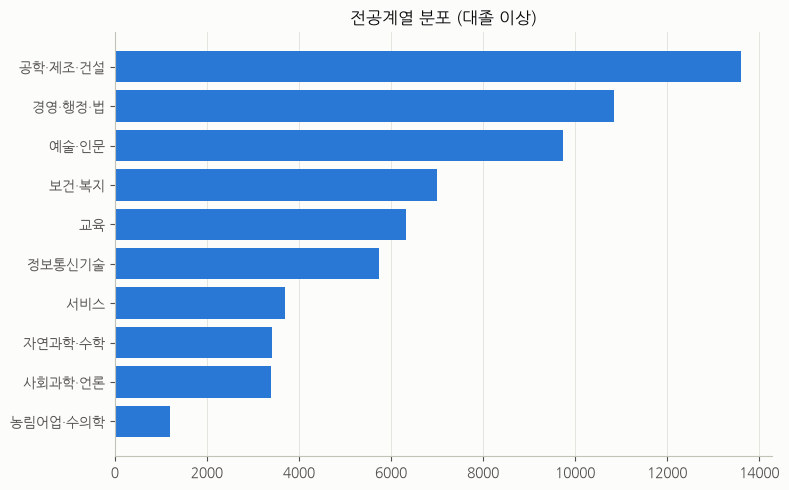

In [26]:
fig, ax = plt.subplots(figsize=(8, 5))
ax.barh(field_table.index[::-1], field_table["인원수"][::-1], color=BLUE)
ax.set_title("전공계열 분포 (대졸 이상)")
ax.grid(axis="x", linewidth=0.6)
ax.set_axisbelow(True)
plt.tight_layout()
plt.show()


## 5. 지역 분석

### 5.1 시도별 인구 분포

In [27]:
province_table = df["province"].value_counts().to_frame("인원수")
province_table["비율(%)"] = (province_table["인원수"] / len(df) * 100).round(2)
province_table


,인원수,비율(%)
province,,
경기,52619,26.31
서울,36996,18.50
부산,12943,6.47
경상남,12391,6.20
인천,11917,5.96
경상북,10081,5.04
대구,9371,4.69
충청남,8344,4.17
전라남,6917,3.46


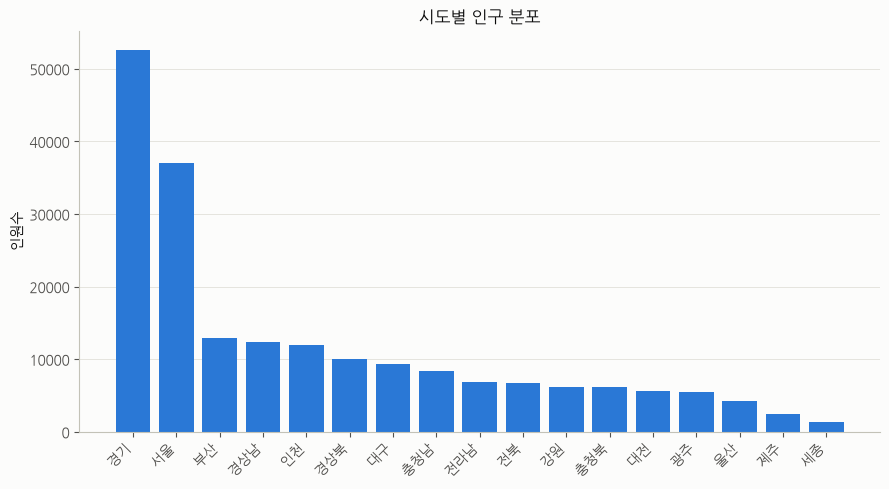

In [28]:
fig, ax = plt.subplots(figsize=(9, 5))
ax.bar(province_table.index, province_table["인원수"], color=BLUE)
ax.set_title("시도별 인구 분포")
ax.set_ylabel("인원수")
plt.xticks(rotation=45, ha="right")
ax.grid(axis="y", linewidth=0.6)
ax.set_axisbelow(True)
plt.tight_layout()
plt.show()


### 5.2 시군구 Top 15 (`시도-시군구` 형식)

In [29]:
district_table = df["district"].value_counts().head(15).to_frame("인원수")
district_table["비율(%)"] = (district_table["인원수"] / len(df) * 100).round(2)
district_table


,인원수,비율(%)
district,,
경기-화성시,3545,1.77
경기-남양주시,2766,1.38
서울-송파구,2522,1.26
인천-서구,2339,1.17
경기-평택시,2290,1.14
서울-강서구,2271,1.14
서울-강남구,2074,1.04
서울-관악구,2073,1.04
대구-달서구,2069,1.03


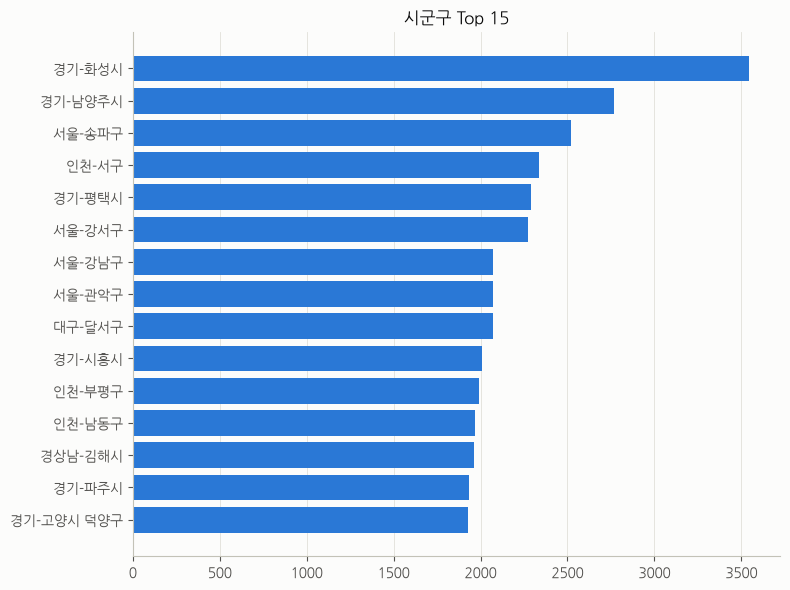

In [30]:
fig, ax = plt.subplots(figsize=(8, 6))
ax.barh(district_table.index[::-1], district_table["인원수"][::-1], color=BLUE)
ax.set_title("시군구 Top 15")
ax.grid(axis="x", linewidth=0.6)
ax.set_axisbelow(True)
plt.tight_layout()
plt.show()


### 5.3 시도별 평균 연령

In [31]:
province_age = df.groupby("province", observed=True)["age"].agg(["mean", "median", "std"]).round(1)
province_age.columns = ["평균연령", "중앙값", "표준편차"]
province_age = province_age.sort_values("평균연령", ascending=False)
province_age


,평균연령,중앙값,표준편차
province,,,
전라남,54.7,55.0,18.1
경상북,53.9,55.0,18.0
전북,53.2,54.0,18.3
강원,53.0,54.0,17.9
경상남,52.4,53.0,17.4
부산,52.3,53.0,17.8
충청북,51.8,53.0,17.8
충청남,51.5,52.0,18.1
대구,51.5,52.0,17.5


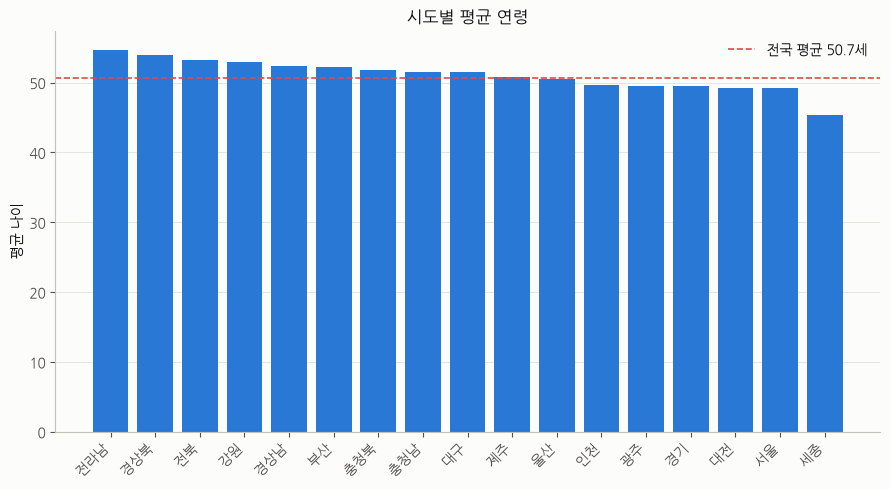

In [32]:
fig, ax = plt.subplots(figsize=(9, 5))
ax.bar(province_age.index, province_age["평균연령"], color=BLUE)
ax.axhline(df["age"].mean(), color=RED, linewidth=1.2, linestyle="--", label=f"전국 평균 {df['age'].mean():.1f}세")
ax.set_title("시도별 평균 연령")
ax.set_ylabel("평균 나이")
plt.xticks(rotation=45, ha="right")
ax.legend(frameon=False)
ax.grid(axis="y", linewidth=0.6)
ax.set_axisbelow(True)
plt.tight_layout()
plt.show()


> 전라남·경상북·전북 등 비수도권 지역은 평균 연령이 높고, 세종·서울·대전 등은 상대적으로 젊습니다. 실제 통계청 인구 고령화 패턴과 일치합니다.

### 5.4 시도별 학력 구성비 (인구 상위 8개 시도)

In [33]:
top_provinces = province_table.head(8).index
sub = df[df["province"].isin(top_provinces)]
edu_province = pd.crosstab(sub["province"], sub["education_level"], normalize="index")[edu_order] * 100
edu_province = edu_province.round(1)
edu_province


education_level,무학,초등학교,중학교,고등학교,2~3년제 전문대학,4년제 대학교,대학원
province,,,,,,,
경기,2.3,6.7,7.4,33.9,15.8,27.9,6.0
경상남,3.7,9.2,10.0,36.9,15.0,22.1,3.1
경상북,4.9,12.7,10.7,35.0,15.3,18.8,2.6
대구,2.5,8.6,9.7,31.3,16.9,26.1,4.8
부산,2.0,9.4,10.0,33.7,13.8,26.9,4.1
서울,1.3,6.0,7.0,28.1,13.6,35.3,8.7
인천,1.8,6.6,8.9,39.8,16.0,23.7,3.3
충청남,3.8,11.8,9.5,36.3,14.3,20.9,3.5


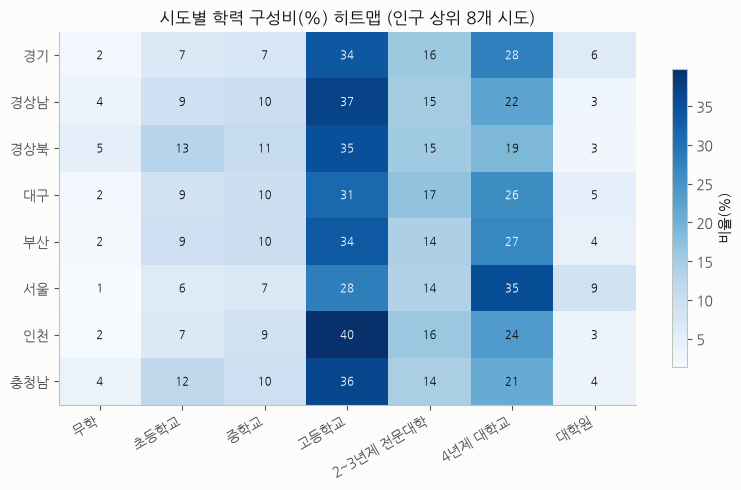

In [34]:
fig, ax = plt.subplots(figsize=(8, 5))
im = ax.imshow(edu_province.values, cmap="Blues", aspect="auto")
ax.set_xticks(range(len(edu_province.columns)))
ax.set_xticklabels(edu_province.columns, rotation=30, ha="right")
ax.set_yticks(range(len(edu_province.index)))
ax.set_yticklabels(edu_province.index)
for i in range(edu_province.shape[0]):
    for j in range(edu_province.shape[1]):
        v = edu_province.values[i, j]
        ax.text(j, i, f"{v:.0f}", ha="center", va="center",
                color="white" if v > 25 else "#0b0b0b", fontsize=8)
ax.set_title("시도별 학력 구성비(%) 히트맵 (인구 상위 8개 시도)")
fig.colorbar(im, ax=ax, shrink=0.8, label="비율(%)")
plt.tight_layout()
plt.show()


> 서울은 `4년제 대학교` 이상 비율이 가장 높고(약 44%), 인천·충청남 등은 `고등학교` 학력 비중이 상대적으로 높습니다.

## 6. 직업 분석

### 6.1 직업 분포 Top 15

In [35]:
occ_table = df["occupation"].value_counts().head(15).to_frame("인원수")
occ_table["비율(%)"] = (occ_table["인원수"] / len(df) * 100).round(2)
occ_table


,인원수,비율(%)
occupation,,
무직,73602,36.80
건물 청소원,3622,1.81
건물 경비원,3428,1.71
경리 사무원,3277,1.64
사무 보조원,2782,1.39
일반 비서,2245,1.12
전화 상담원,2235,1.12
시설 경비원,2178,1.09
하역 및 적재 관련 단순 종사원,1842,0.92


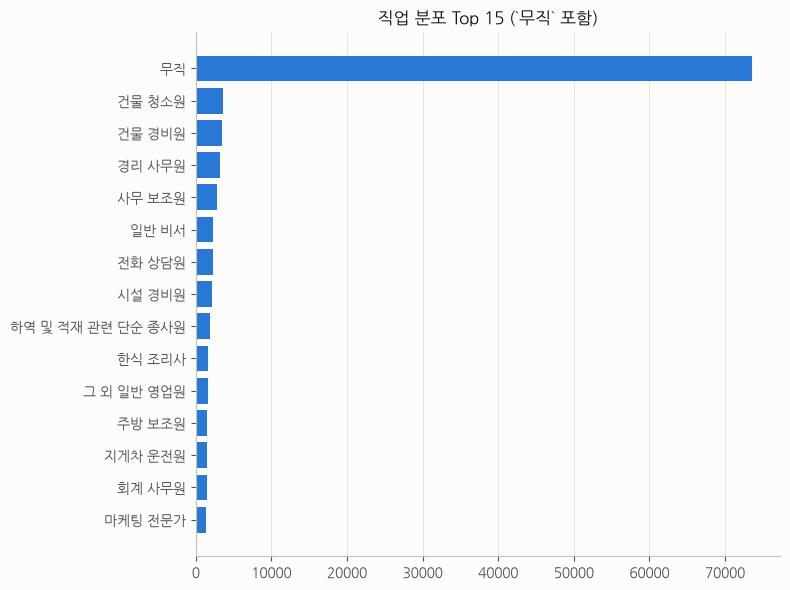

In [36]:
fig, ax = plt.subplots(figsize=(8, 6))
ax.barh(occ_table.index[::-1], occ_table["인원수"][::-1], color=BLUE)
ax.set_title("직업 분포 Top 15 (`무직` 포함)")
ax.grid(axis="x", linewidth=0.6)
ax.set_axisbelow(True)
plt.tight_layout()
plt.show()


### 6.2 직업 Top 12 성별 구성비 (`무직` 제외)

In [37]:
occ_no_none = df[df["occupation"] != "무직"]
top_occ = occ_no_none["occupation"].value_counts().head(12).index
occ_sex = pd.crosstab(
    occ_no_none.loc[occ_no_none["occupation"].isin(top_occ), "occupation"],
    occ_no_none.loc[occ_no_none["occupation"].isin(top_occ), "sex"],
)
occ_sex = occ_sex.loc[top_occ]
occ_sex_pct = (occ_sex.div(occ_sex.sum(axis=1), axis=0) * 100).round(1)
occ_sex_pct


sex,남자,여자
occupation,,
건물 청소원,8.2,91.8
건물 경비원,83.6,16.4
경리 사무원,46.5,53.5
사무 보조원,49.2,50.8
일반 비서,31.2,68.8
전화 상담원,44.0,56.0
시설 경비원,76.1,23.9
하역 및 적재 관련 단순 종사원,78.5,21.5
한식 조리사,11.2,88.8


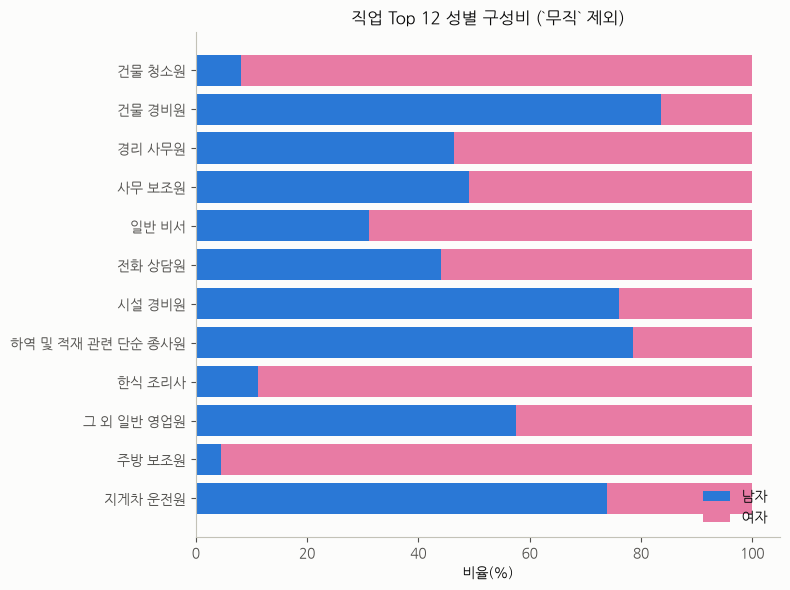

In [38]:
male_col = [c for c in occ_sex_pct.columns if c == "남자"][0]
female_col = [c for c in occ_sex_pct.columns if c == "여자"][0]

fig, ax = plt.subplots(figsize=(8, 6))
y = np.arange(len(occ_sex_pct))
ax.barh(y, occ_sex_pct[male_col], color=CAT[0], label="남자")
ax.barh(y, occ_sex_pct[female_col], left=occ_sex_pct[male_col], color=CAT[6], label="여자")
ax.set_yticks(y)
ax.set_yticklabels(occ_sex_pct.index)
ax.invert_yaxis()
ax.set_xlabel("비율(%)")
ax.set_title("직업 Top 12 성별 구성비 (`무직` 제외)")
ax.legend(frameon=False, loc="lower right")
plt.tight_layout()
plt.show()


> `건물 청소원`·`주방 보조원`·`한식 조리사`는 여성 비중이 압도적으로 높고, `건물 경비원`·`하역 및 적재 관련 단순 종사원`은 남성 비중이 높아 뚜렷한 직업 내 성별 분리가 나타납니다.

## 7. 페르소나 텍스트 분석

데이터셋에는 인물별로 7종의 자연어 페르소나 설명(`professional_persona`, `sports_persona`, `arts_persona`, `travel_persona`, `culinary_persona`, `family_persona`, `persona`)이 들어 있습니다. 각 텍스트의 길이(글자 수)를 분석합니다.

### 7.1 페르소나 유형별 글자 수 기술통계

In [39]:
persona_cols = [
    "professional_persona", "sports_persona", "arts_persona",
    "travel_persona", "culinary_persona", "family_persona", "persona",
]
persona_labels = ["전문", "스포츠", "예술", "여행", "음식", "가족", "종합"]

len_df = pd.DataFrame({c: df[c].str.len() for c in persona_cols})
len_df.columns = persona_labels
len_df.describe().round(1)


,전문,스포츠,예술,여행,음식,가족,종합
count,200000.0,200000.0,200000.0,200000.0,200000.0,200000.0,200000.0
mean,159.5,133.7,138.2,135.1,142.0,143.9,81.5
std,30.3,26.2,26.3,26.5,27.9,27.9,10.6
min,64.0,55.0,54.0,54.0,60.0,63.0,45.0
25%,140.0,116.0,121.0,119.0,123.0,126.0,74.0
50%,163.0,137.0,142.0,139.0,146.0,149.0,81.0
75%,181.0,152.0,157.0,153.0,162.0,164.0,88.0
max,298.0,237.0,260.0,246.0,277.0,250.0,168.0


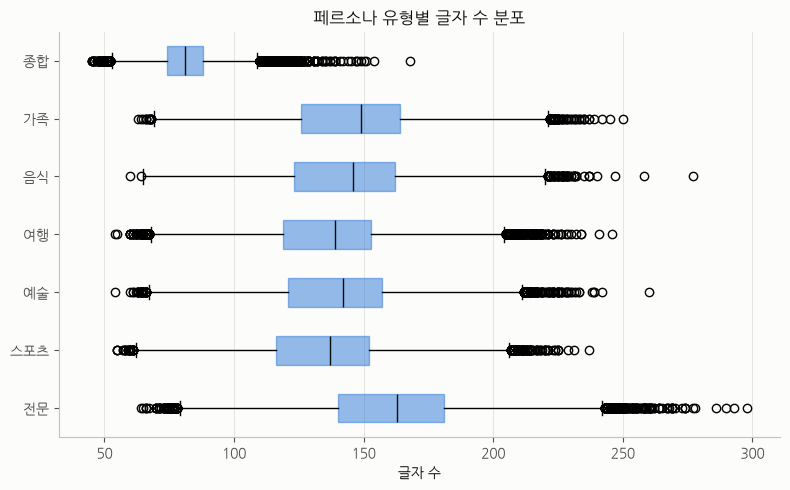

In [40]:
fig, ax = plt.subplots(figsize=(8, 5))
bp = ax.boxplot([len_df[c].values for c in persona_labels], vert=False, patch_artist=True)
for patch in bp["boxes"]:
    patch.set_facecolor(BLUE)
    patch.set_alpha(0.5)
    patch.set_edgecolor(BLUE)
for median in bp["medians"]:
    median.set_color("#0b0b0b")
ax.set_yticks(range(1, len(persona_labels) + 1))
ax.set_yticklabels(persona_labels)
ax.set_title("페르소나 유형별 글자 수 분포")
ax.set_xlabel("글자 수")
ax.grid(axis="x", linewidth=0.6)
ax.set_axisbelow(True)
plt.tight_layout()
plt.show()


### 7.2 나이 vs 종합 페르소나(`persona`) 길이

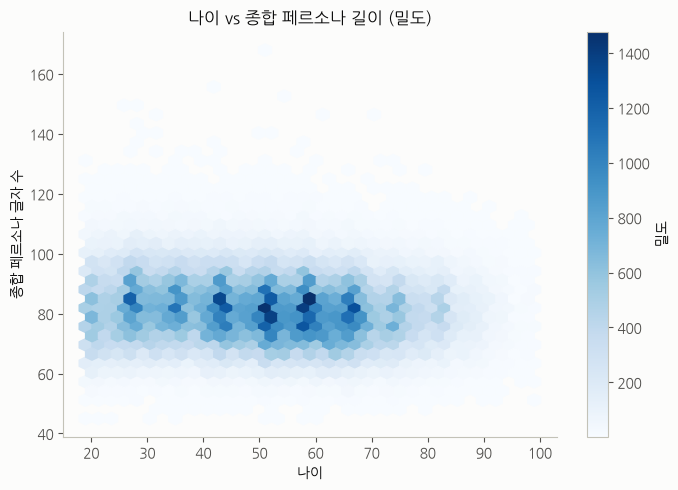

상관계수(age, persona_len): -0.091


In [41]:
df["persona_len"] = df["persona"].str.len()

fig, ax = plt.subplots(figsize=(7, 5))
hb = ax.hexbin(df["age"], df["persona_len"], gridsize=35, cmap="Blues", mincnt=1)
ax.set_xlabel("나이")
ax.set_ylabel("종합 페르소나 글자 수")
ax.set_title("나이 vs 종합 페르소나 길이 (밀도)")
cb = fig.colorbar(hb, ax=ax)
cb.set_label("밀도")
plt.tight_layout()
plt.show()

print(f"상관계수(age, persona_len): {df['age'].corr(df['persona_len']):.3f}")


### 7.3 나이 · 페르소나 길이 상관관계 히트맵

In [42]:
num_df = pd.DataFrame({"age": df["age"]})
for c, lbl in zip(persona_cols, persona_labels):
    num_df[lbl] = df[c].str.len()
corr = num_df.corr()
corr


,age,전문,스포츠,예술,여행,음식,가족,종합
age,1.000000,-0.264858,-0.168746,-0.172485,-0.165283,-0.145642,-0.171886,-0.090561
전문,-0.264858,1.000000,0.787196,0.787290,0.780204,0.774114,0.781291,0.200271
스포츠,-0.168746,0.787196,1.000000,0.884316,0.899689,0.873343,0.879785,0.173312
예술,-0.172485,0.787290,0.884316,1.000000,0.895455,0.875574,0.881232,0.169187
여행,-0.165283,0.780204,0.899689,0.895455,1.000000,0.885222,0.896471,0.164982
음식,-0.145642,0.774114,0.873343,0.875574,0.885222,1.000000,0.885327,0.169986
가족,-0.171886,0.781291,0.879785,0.881232,0.896471,0.885327,1.000000,0.169884
종합,-0.090561,0.200271,0.173312,0.169187,0.164982,0.169986,0.169884,1.000000


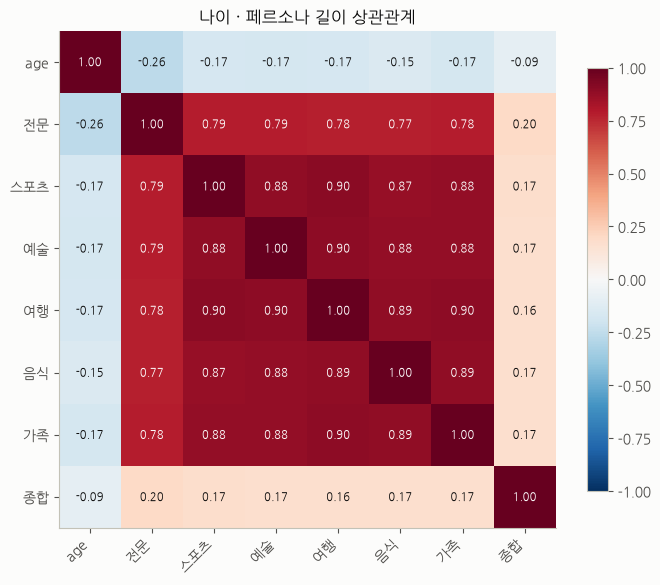

In [43]:
fig, ax = plt.subplots(figsize=(7, 6))
im = ax.imshow(corr.values, cmap="RdBu_r", vmin=-1, vmax=1)
ax.set_xticks(range(len(corr.columns)))
ax.set_xticklabels(corr.columns, rotation=45, ha="right")
ax.set_yticks(range(len(corr.columns)))
ax.set_yticklabels(corr.columns)
for i in range(corr.shape[0]):
    for j in range(corr.shape[1]):
        v = corr.values[i, j]
        ax.text(j, i, f"{v:.2f}", ha="center", va="center", fontsize=8,
                color="white" if abs(v) > 0.5 else "#0b0b0b")
fig.colorbar(im, ax=ax, shrink=0.8)
ax.set_title("나이 · 페르소나 길이 상관관계")
plt.tight_layout()
plt.show()


> 6가지 상세 페르소나(전문·스포츠·예술·여행·음식·가족) 길이는 서로 강한 양의 상관관계(0.77~0.90)를 보입니다. 즉, 한 인물의 설명이 전반적으로 풍부하면 모든 페르소나 유형에서 함께 길어지는 경향입니다. 반면 나이와는 약한 음의 상관(특히 `전문 페르소나`는 -0.26)을 보이는데, 고령층·무직 비중이 높아지며 전문 경력 서술이 상대적으로 짧아지는 것으로 해석됩니다.

## 8. 취미 · 기술 리스트 분석

`hobbies_and_interests_list`, `skills_and_expertise_list`는 문자열로 직렬화된 파이썬 리스트입니다. `ast.literal_eval`로 파싱해 분석합니다. (전체 표본을 파싱하면 시간이 걸리므로 최대 `PARSE_LIMIT`건만 사용합니다.)

### 8.1 취미 개수 분포 & 상위 취미 문구

In [44]:
PARSE_LIMIT = min(len(df), 80_000)
hobbies_parsed = df["hobbies_and_interests_list"].head(PARSE_LIMIT).apply(ast.literal_eval)

n_hobbies = hobbies_parsed.apply(len)
n_hobbies.describe().round(2).to_frame("취미_개수")


,취미_개수
count,80000.00
mean,4.41
std,0.49
min,3.00
25%,4.00
50%,4.00
75%,5.00
max,6.00


In [45]:
hobby_counter = Counter()
for lst in hobbies_parsed:
    hobby_counter.update(lst)

top_hobbies = pd.DataFrame(hobby_counter.most_common(20), columns=["취미 문구", "빈도"])
top_hobbies


,취미 문구,빈도
0,지역 배드민턴 동호회 활동,1730
1,임영웅 노래 감상,1297
2,유튜브 트로트 영상 시청,1272
3,베란다 텃밭 가꾸기,1100
4,네이버 웹툰 정주행,917
5,모바일 퍼즐 게임,806
6,리그 오브 레전드 게임,708
7,지역 배드민턴 클럽 활동,672
8,동네 목욕탕 사우나,668
9,동네 사우나에서 반신욕 하기,653


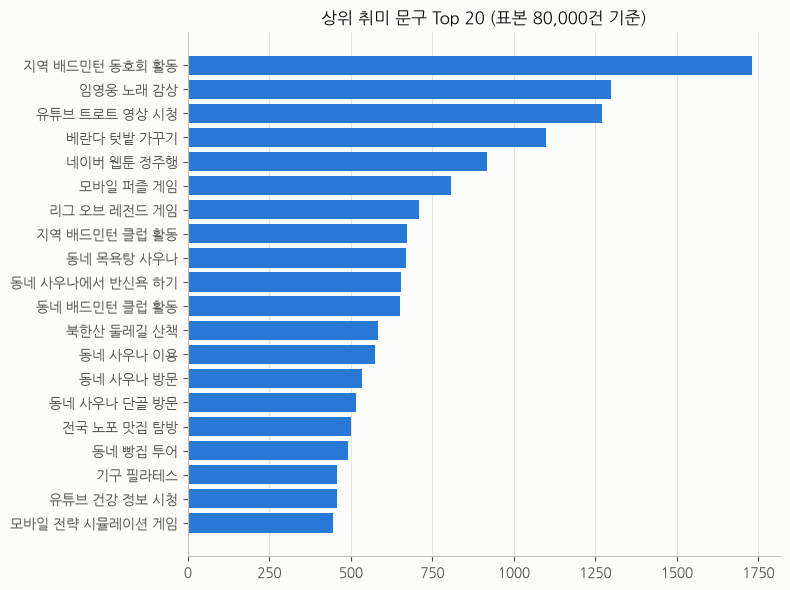

In [46]:
fig, ax = plt.subplots(figsize=(8, 6))
ax.barh(top_hobbies["취미 문구"][::-1], top_hobbies["빈도"][::-1], color=BLUE)
ax.set_title(f"상위 취미 문구 Top 20 (표본 {PARSE_LIMIT:,}건 기준)")
ax.grid(axis="x", linewidth=0.6)
ax.set_axisbelow(True)
plt.tight_layout()
plt.show()


### 8.2 전문 기술(`skills_and_expertise`) 단어 빈도 Top 20

In [47]:
skills_parsed = df["skills_and_expertise_list"].head(PARSE_LIMIT).apply(ast.literal_eval)

word_counter = Counter()
for lst in skills_parsed:
    for phrase in lst:
        for tok in phrase.split():
            if len(tok) > 1:
                word_counter[tok] += 1

top_words = pd.DataFrame(word_counter.most_common(20), columns=["단어", "빈도"])
top_words


,단어,빈도
0,관리,54115
1,분석,20177
2,효율적인,20027
3,갈등,18749
4,중재,18109
5,최적화,17330
6,설계,17181
7,작성,14083
8,지역,13123
9,안전,12432


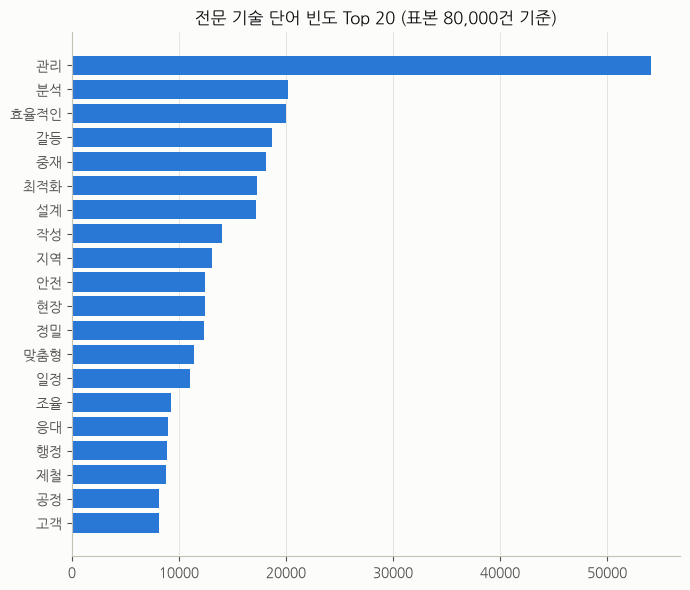

In [48]:
fig, ax = plt.subplots(figsize=(7, 6))
ax.barh(top_words["단어"][::-1], top_words["빈도"][::-1], color=BLUE)
ax.set_title(f"전문 기술 단어 빈도 Top 20 (표본 {PARSE_LIMIT:,}건 기준)")
ax.grid(axis="x", linewidth=0.6)
ax.set_axisbelow(True)
plt.tight_layout()
plt.show()


## 9. 종합 요약 테이블 저장

지금까지 만든 주요 요약 테이블을 CSV로 저장합니다. 발표 자료나 리포트에 바로 활용할 수 있습니다.

In [49]:
import os

OUT_DIR = "eda_outputs"
os.makedirs(OUT_DIR, exist_ok=True)

summary_tables = {
    "sex_distribution": sex_table,
    "age_group_distribution": age_group_table,
    "marital_status_distribution": marital_table,
    "age_group_x_marital_status": age_marital,
    "family_type_top10": family_type_table,
    "housing_type_distribution": housing_table,
    "education_level_distribution": edu_table,
    "bachelors_field_distribution": field_table,
    "province_distribution": province_table,
    "district_top15": district_table,
    "province_avg_age": province_age,
    "province_x_education_heatmap": edu_province,
    "occupation_top15": occ_table,
    "occupation_top12_x_sex": occ_sex_pct,
    "persona_length_describe": len_df.describe().round(1),
    "age_persona_length_corr": corr,
    "top_hobby_phrases": top_hobbies.set_index("취미 문구"),
    "top_skill_words": top_words.set_index("단어"),
}

for name, table in summary_tables.items():
    table.to_csv(os.path.join(OUT_DIR, f"{name}.csv"), encoding="utf-8-sig")

print(f"{len(summary_tables)}개 요약 테이블을 '{OUT_DIR}/' 폴더에 CSV로 저장했습니다.")
sorted(os.listdir(OUT_DIR))


18개 요약 테이블을 'eda_outputs/' 폴더에 CSV로 저장했습니다.


['age_group_distribution.csv',
 'age_group_x_marital_status.csv',
 'age_persona_length_corr.csv',
 'bachelors_field_distribution.csv',
 'district_top15.csv',
 'education_level_distribution.csv',
 'family_type_top10.csv',
 'housing_type_distribution.csv',
 'marital_status_distribution.csv',
 'occupation_top12_x_sex.csv',
 'occupation_top15.csv',
 'persona_length_describe.csv',
 'province_avg_age.csv',
 'province_distribution.csv',
 'province_x_education_heatmap.csv',
 'sex_distribution.csv',
 'top_hobby_phrases.csv',
 'top_skill_words.csv']

## 10. 결론 요약

- **인구구조**: 60대 이상에서 여성 비중이 뚜렷이 높아지는 항아리형(고령화) 구조. 전국 평균 연령은 약 50세.
- **혼인상태**: 19-29세는 미혼이 91%지만, 40대부터는 배우자 있음이 70% 이상으로 역전. 80대 이상은 사별 비중이 58%로 급증.
- **학력**: 서울(대졸 이상 약 44%)이 전국에서 가장 높고, 비수도권은 고졸 비중이 상대적으로 높음.
- **지역**: 경기·서울에 인구가 집중되어 있으며, 전라남·경상북 등 비수도권은 평균 연령이 높아 지역 간 고령화 격차가 뚜렷함.
- **직업**: `무직` 비중이 가장 크고(고령 인구 반영), 특정 직종(청소·주방·조리 vs 경비·하역)에서 강한 성별 분리가 관찰됨.
- **페르소나 텍스트**: 6종 세부 페르소나 길이는 서로 강한 상관관계를 가지며, 나이가 많을수록(특히 전문 페르소나가) 다소 짧아지는 경향.
- **취미/기술**: 동호회 활동, 트로트·유튜브 시청, 산책·둘레길 등 실생활 밀착형 취미가 상위권을 차지.

> ⚠️ 이 데이터셋은 실제 개인정보가 아닌 **완전 합성 데이터**이며, 변수 간 독립성 가정 하에 생성되었습니다. 실제 사회 현상의 인과관계 분석이 아닌, LLM 학습/평가용 합성 페르소나 데이터로 활용하는 것을 목적으로 합니다.
